# History ablation — training diagnostics

Verifies every training run in the 4x2x3x5 grid completed: reached the full epoch budget, wrote a checkpoint, and did not collapse (effective rank stays well above 1). Reads each run's Lightning `metrics.csv`.

In [29]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def _repo_root(start):
    for c in [start.resolve(), *start.resolve().parents]:
        if (c / "plot_style.py").exists() and (c / "experiments").is_dir():
            return c
    return start.resolve()


REPO_ROOT = _repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

try:
    from plot_style import FULL_WIDTH, apply_matplotlib_style, palette
    apply_matplotlib_style()
except Exception:
    FULL_WIDTH = 6.5
    palette = {"Dark Blue": "tab:blue", "Dark Red": "tab:red",
               "Light Blue": "#9ecae1", "Light Red": "#fcbba1",
               "Dark Grey": "0.3"}

EXP_DIR = REPO_ROOT / "experiments" / "history_ablation"
MANIFEST = EXP_DIR / "generated_configs" / "manifest.tsv"
ENV_ORDER = ["TwoRoom", "Reacher", "Push-T", "OGBench-Cube"]
METHOD_LABELS = {"idr": "IDR", "sigreg": "SIGReg"}
HISTORIES = [1, 2, 3]


In [30]:
# Load the grid and locate each run's Lightning CSV log.
grid = pd.read_csv(MANIFEST, sep="\t")
grid["history"] = grid["history"].astype(int)
grid["seed"] = grid["seed"].astype(int)
TRAIN_ROOT = EXP_DIR / "results" / "train"


def metrics_csv(run_name):
    p = TRAIN_ROOT / run_name / "lightning" / "local" / "metrics.csv"
    return p if p.exists() else None


def load_metrics(run_name):
    p = metrics_csv(run_name)
    if p is None:
        return None
    try:
        return pd.read_csv(p)
    except Exception:
        return None


def first_col(df, *substrings):
    for s in substrings:
        hits = [c for c in df.columns if s in c]
        if hits:
            return hits[0]
    return None


print(f"Grid: {len(grid)} runs. CSV logs found: "
      f"{sum(metrics_csv(r) is not None for r in grid['run_name'])}")


Grid: 120 runs. CSV logs found: 120


In [31]:
# Completion table: epochs reached, checkpoint present, final losses, effective rank.
def summarize(run):
    run_name = run["run_name"]
    # final_embeddings.pt is written only after training finishes (small; the
    # large last.ckpt need not be transferred for diagnostics).
    done = (TRAIN_ROOT / run_name / "final_embeddings.pt").exists()
    df = load_metrics(run_name)
    row = {
        "run_name": run_name, "env": run["env_label"], "method": run["method"],
        "history": run["history"], "seed": run["seed"],
        "has_final": done, "max_epoch": np.nan,
        "final_train_loss": np.nan, "final_val_loss": np.nan,
        "final_eff_rank": np.nan, "status": "missing",
    }
    if df is None:
        return row
    if "epoch" in df.columns and df["epoch"].notna().any():
        row["max_epoch"] = int(df["epoch"].max())
    tcol = first_col(df, "train/loss", "fit/loss", "train/pred_loss", "fit/pred_loss")
    vcol = first_col(df, "val/pred_loss", "validate/pred_loss", "val/loss")
    ecol = first_col(df, "effective_rank")
    for key, col in [("final_train_loss", tcol), ("final_val_loss", vcol),
                     ("final_eff_rank", ecol)]:
        if col is not None and df[col].notna().any():
            row[key] = float(df[col].dropna().iloc[-1])
    row["status"] = "ok" if done and (row["max_epoch"] or 0) >= 9 else "incomplete"
    return row


completion = pd.DataFrame([summarize(r) for _, r in grid.iterrows()])
n_ok = (completion["status"] == "ok").sum()
print(f"Complete: {n_ok}/{len(completion)}")
if n_ok < len(completion):
    print("\nIncomplete / missing runs:")
    display(completion[completion["status"] != "ok"]
            [["run_name", "has_final", "max_epoch", "status"]])

# Collapse check: flag any run whose final effective rank is suspiciously low.
low_rank = completion[completion["final_eff_rank"] < 2.0].dropna(subset=["final_eff_rank"])
if len(low_rank):
    print("\nPossible collapse (effective rank < 2):")
    display(low_rank[["run_name", "final_eff_rank", "final_val_loss"]])
else:
    print("No collapse flagged (all effective ranks >= 2 where logged).")

display(completion.groupby(["env", "method", "history"])["status"]
        .agg(lambda s: f"{(s=='ok').sum()}/{len(s)}").unstack("history"))


Complete: 120/120
No collapse flagged (all effective ranks >= 2 where logged).


history                1    2    3
env          method               
OGBench-Cube idr     5/5  5/5  5/5
             sigreg  5/5  5/5  5/5
Push-T       idr     5/5  5/5  5/5
             sigreg  5/5  5/5  5/5
Reacher      idr     5/5  5/5  5/5
             sigreg  5/5  5/5  5/5
TwoRoom      idr     5/5  5/5  5/5
             sigreg  5/5  5/5  5/5

Available loss/rank columns: ['fit/inv_loss_epoch', 'fit/inv_loss_step', 'fit/loss_epoch', 'fit/loss_step', 'fit/pred_loss_epoch', 'fit/pred_loss_step', 'validate/effective_rank', 'validate/inv_loss', 'validate/loss', 'validate/pred_loss']


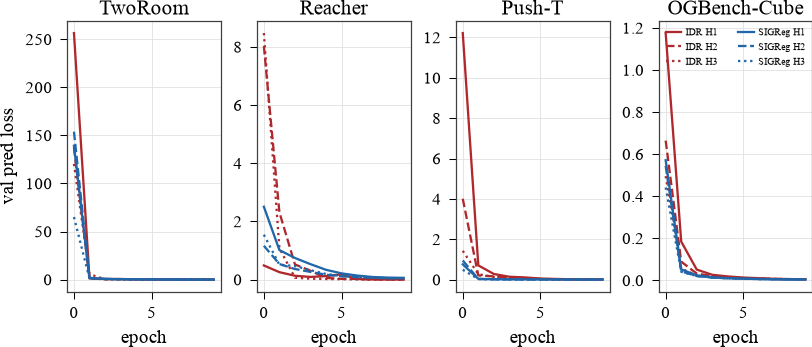

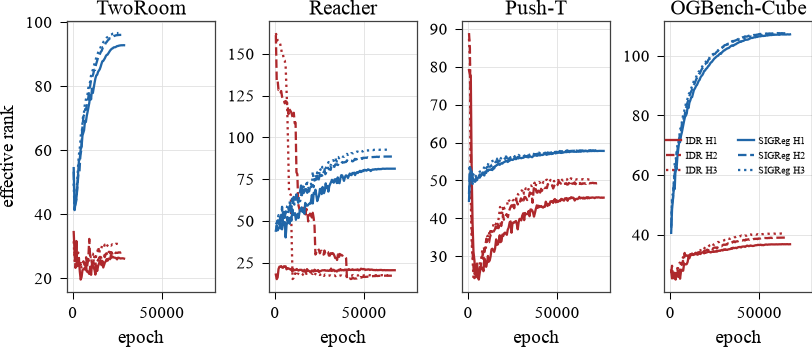

In [32]:
# Training curves faceted by environment, one line per (method, history), averaged over seeds.
_sample = next((load_metrics(r) for r in grid["run_name"]
                if load_metrics(r) is not None), None)
if _sample is not None:
    print("Available loss/rank columns:",
          [c for c in _sample.columns if "loss" in c or "rank" in c])


def pick_col(df, stem, prefer=("val", "validate"), avoid=()):
    """Column whose name contains `stem`; prefer val-stage, else any (e.g. train)."""
    cols = [c for c in df.columns if stem in c and not any(a in c for a in avoid)]
    if not cols:
        return None
    for c in cols:
        if any(p in c for p in prefer):
            return c
    return cols[0]


def curve(run_name, stem, **kw):
    df = load_metrics(run_name)
    if df is None:
        return None, None
    yc = pick_col(df, stem, **kw)
    if yc is None:
        return None, None
    for xcol in ("epoch", "step"):
        if xcol in df.columns:
            sub = df[[xcol, yc]].dropna()
            if not sub.empty:
                g = sub.groupby(xcol)[yc].mean()
                return g.index.to_numpy(), g.to_numpy()
    ys = df[yc].dropna()
    if ys.empty:
        return None, None
    return np.arange(len(ys)), ys.to_numpy()


def facet(stem, title, **kw):
    fig, axes = plt.subplots(1, len(ENV_ORDER), figsize=(FULL_WIDTH, 2.4),
                             constrained_layout=True, sharex=True)
    colors = {"idr": palette.get("Dark Red", "tab:red"),
              "sigreg": palette.get("Dark Blue", "tab:blue")}
    styles = {1: "-", 2: "--", 3: ":"}
    n_curves = 0
    for ax, env in zip(axes, ENV_ORDER):
        g = grid[grid["env_label"] == env]
        for method in ["idr", "sigreg"]:
            for h in HISTORIES:
                runs = g[(g["method"] == method) & (g["history"] == h)]["run_name"]
                xs, ys = [], []
                for rn in runs:
                    x, y = curve(rn, stem, **kw)
                    if x is not None:
                        xs.append(x); ys.append(y)
                if not xs:
                    continue
                n = min(len(x) for x in xs)
                ym = np.nanmean(np.stack([y[:n] for y in ys]), axis=0)
                ax.plot(xs[0][:n], ym, styles[h], color=colors[method], lw=1.1,
                        label=f"{METHOD_LABELS[method]} H{h}")
                n_curves += 1
        ax.set_title(env, pad=3)
        ax.set_xlabel("epoch")
        ax.grid(True, lw=0.4)
    axes[0].set_ylabel(title)
    handles, labels = [], []
    for ax in axes:
        for hd, lb in zip(*ax.get_legend_handles_labels()):
            if lb not in labels:
                handles.append(hd); labels.append(lb)
    if handles:
        axes[-1].legend(handles, labels, fontsize=5, ncol=2, loc="best")
    else:
        print(f"[warn] no curves for {title!r}: no column contains {stem!r} "
              "(see the list printed above)")
    plt.show()


# Prefer the epoch-reduced curve; avoid per-step columns to keep one point per epoch.
facet("pred_loss", "val pred loss", prefer=("val", "validate"), avoid=("_step",))
facet("rank", "effective rank", prefer=("val", "validate"))
